<hr>
<h1><center>| Projet 4: Construisez un modèle de scoring |</center></h1>

<hr>
<h1><center>| Analyse exploratoir |</center></h1>
<br>
<br>

>__Réalisé par : Said Arrazouaki__

## Sommaire 

1. [Introduction](#1-introduction)

2. [Chargement et préparation des données](#2-chargement-et-preparation-des-donnees)

3. [Analyse exploratoire des données](#3-analyse-exploratoire-des-donnees)

<hr>

## Inroduction

La société financière "Prêt à dépenser" souhaite pouvoir utiliser un modèle de scoring l'aidant à prédire le risque de défaut de paiement d'un client ayant peu ou pas d'historique de prêt.
Le modèle devra permettre aux conseillers qui l'utilisent de comprendre les motifs de l'acceptation ou du rejet de la demande de prêt.

## Chargement des données

In [44]:
# Importation des bibliothéques
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_row", 124)
pd.set_option("display.max_columns", None)
warnings.filterwarnings("ignore")
sns.set_theme(style="darkgrid")

In [45]:
# Les fichiers contenus dans le dossier data
files = os.listdir("./data")
files

['application_test.csv',
 'application_train.csv',
 'bureau.csv',
 'bureau_balance.csv',
 'credit_card_balance.csv',
 'HomeCredit_columns_description.csv',
 'installments_payments.csv',
 'POS_CASH_balance.csv',
 'previous_application.csv',
 'sample_submission.csv']

<img src="./img/img.png" alt="Data Structure" width="800">

In [46]:
# Chargement des données d'entraînement
application_train = pd.read_csv("./data/application_train.csv")
# Afficher les premières lignes du jeu de données
application_train.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.018801,-9461,-637,-3648.0,-2120,NaN,1,1,0,1,1,0,Laborers,1.0,2,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.083037,0.262949,0.139376,0.0247,0.0369,0.9722,0.6192,0.0143,0.00,0.0690,0.0833,0.1250,0.0369,0.0202,0.0190,0.0000,0.0000,0.0252,0.0383,0.9722,0.6341,0.0144,0.0000,0.0690,0.0833,0.1250,0.0377,0.022,0.0198,0.0,0.0,0.0250,0.0369,0.9722,0.6243,0.0144,0.00,0.0690,0.0833,0.1250,0.0375,0.0205,0.0193,0.0000,0.00,reg oper account,block of flats,0.0149,"Stone, brick",No,2.0,2.0,2.0,2.0,-1134.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,Family,State servant,Higher education,Married,House / apartment,0.003541,-16765,-1188,-1186.0,-291,NaN,1,1,0,1,1,0,Core staff,2.0,1,1,MONDAY,11,0,0,0,0,0,0,School,0.311267,0.622246,NaN,0.0959,0.0529,0.9851,0.7960,0.0605,0.08,0.0345,0.2917,0.3333,0.0130,0.0773,0.0549,0.0039,0.0098,0.0924,0.0538,0.9851,0.8040,0.0497,0.0806,0.0345,0.2917,0.3333,0.0128,0.079,0.0554,0.0,0.0,0.0968,0.0529,0.9851,0.7987,0.0608,0.08,0.0345,0.2917,0.3333,0.0132,0.0787,0.0558,0.0039,0.01,reg oper account,block of flats,0.0714,Block,No,1.0,0.0,1.0,0.0,-828.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,135000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.010032,-19046,-225,-4260.0,-2531,26.0,1,1,1,1,1,0,Laborers,1.0,2,2,MONDAY,9,0,0,0,0,0,0,Government,NaN,0.555912,0.729567,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,

In [47]:
print("Training data shape: ", application_train.shape)

Training data shape:  (307511, 122)


In [48]:
application_train.dtypes.value_counts()

float64    65
int64      41
object     16
Name: count, dtype: int64

### Description des colonnes

In [49]:
columns_description = pd.read_csv(
    "./data/HomeCredit_columns_description.csv", encoding="ISO-8859-1"
)
columns_description.loc[
    columns_description["Table"] == "application_{train|test}.csv",
    ["Row", "Description"],
].head(10)


,Row,Description
0,SK_ID_CURR,ID of loan in our sample
1,TARGET,"Target variable (1 - client with payment difficulties: he/she had late payment more than X days on at least one of the first Y installments of the loan in our sample, 0 - all other cases)"
2,NAME_CONTRACT_TYPE,Identification if loan is cash or revolving
3,CODE_GENDER,Gender of the client
4,FLAG_OWN_CAR,Flag if the client owns a car
5,FLAG_OWN_REALTY,Flag if client owns a house or flat
6,CNT_CHILDREN,Number of children the client has
7,AMT_INCOME_TOTAL,Income of the client
8,AMT_CREDIT,Credit amount of the loan
9,AMT_ANNUITY,Loan annuity


### Les valeurs manquantes

In [50]:
# Fonction pour calculer les valeurs manquantes par colonne
def missing_values_table(df):
    # Total des valeurs manquantes
    mis_val = df.isna().sum()

    # Pourcentage de valeurs manquantes
    mis_val_percent = 100 * df.isna().mean()

    # Créer un tableau avec les résultats
    mis_val_table = pd.concat([mis_val, mis_val_percent], axis=1)

    # Renommer les colonnes
    mis_val_table_ren_columns = mis_val_table.rename(
        columns={0: "Valeurs Manquantes", 1: "% des Valeurs Totales"}
    )

    # Trier le tableau par pourcentage de valeurs manquantes, ordre décroissant
    mis_val_table_ren_columns = (
        mis_val_table_ren_columns[mis_val_table_ren_columns.iloc[:, 1] != 0]
        .sort_values("% des Valeurs Totales", ascending=False)
        .round(1)
    )

    # Afficher un résumé des informations
    print(
        "Le DataFrame sélectionné contient " + str(df.shape[1]) + " colonnes.\n"
        "Il y a "
        + str(mis_val_table_ren_columns.shape[0])
        + " colonnes qui ont des valeurs manquantes."
    )

    # Retourner le DataFrame avec les informations sur les valeurs manquantes
    if mis_val_table_ren_columns.shape[0] != 0:
        return mis_val_table_ren_columns
    else:
        return

In [51]:
missing_values_table(application_train).head()

Le DataFrame sélectionné contient 122 colonnes.
Il y a 67 colonnes qui ont des valeurs manquantes.


,Valeurs Manquantes,% des Valeurs Totales
COMMONAREA_MEDI,214865,69.9
COMMONAREA_MODE,214865,69.9
COMMONAREA_AVG,214865,69.9
NONLIVINGAPARTMENTS_MODE,213514,69.4
NONLIVINGAPARTMENTS_MEDI,213514,69.4


In [52]:
application_train["ORGANIZATION_TYPE"].value_counts()

ORGANIZATION_TYPE
Business Entity Type 3    67992
XNA                       55374
Self-employed             38412
Other                     16683
Medicine                  11193
Business Entity Type 2    10553
Government                10404
School                     8893
Trade: type 7              7831
Kindergarten               6880
Construction               6721
Business Entity Type 1     5984
Transport: type 4          5398
Trade: type 3              3492
Industry: type 9           3368
Industry: type 3           3278
Security                   3247
Housing                    2958
Industry: type 11          2704
Military                   2634
Bank                       2507
Agriculture                2454
Police                     2341
Transport: type 2          2204
Postal                     2157
Security Ministries        1974
Trade: type 2              1900
Restaurant                 1811
Services                   1575
University                 1327
Industry: type 7      

In [53]:
application_train.isna().sum()["ORGANIZATION_TYPE"]

np.int64(0)

In [54]:
# Supprimer les colonnes avec plus de 50 % de valeurs manquantes
seuil = 0.5  # Seuil de 50 %
application_train = application_train.loc[:, application_train.isnull().mean() < seuil]


## Analyse exploratoire des données

#### La variable ``TARGET``

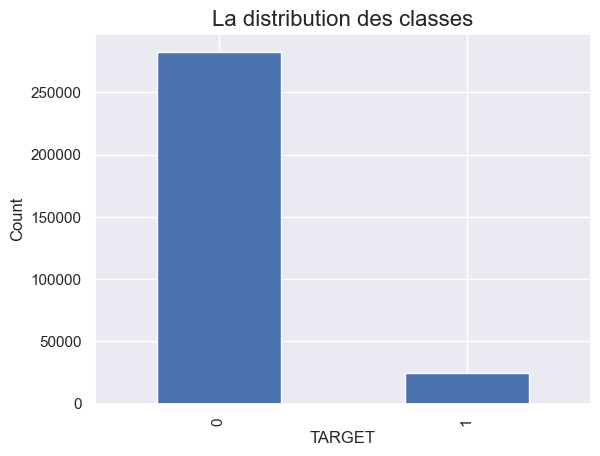

In [55]:
application_train["TARGET"].value_counts().plot.bar()
_ = plt.ylabel("Count")
_ = plt.title("La distribution des classes", fontsize=16)

#### La variable ``CODE_GENDER``

In [56]:
application_train["CODE_GENDER"].value_counts()

CODE_GENDER
F      202448
M      105059
XNA         4
Name: count, dtype: int64

In [57]:
application_train = application_train[application_train["CODE_GENDER"] != "XNA"]

Un point important à surveiller lors de l'analyse exploratoire des données (EDA) est la présence d'anomalies. Ces anomalies peuvent provenir d'erreurs de saisie, de problèmes avec les instruments de mesure, ou être des valeurs valides mais inhabituelles. Pour les détecter, on peut utiliser la méthode describe, qui permet d'examiner les statistiques d'une colonne. Par exemple, dans la colonne DAYS_BIRTH, les valeurs sont négatives car elles représentent l'âge en jours avant la demande de prêt. Pour obtenir l'âge en années, il suffit de multiplier les valeurs par -1 et de les diviser par 365.

In [58]:
(application_train["DAYS_BIRTH"] / -365).describe()


count    307507.000000
mean         43.937061
std          11.956116
min          20.517808
25%          34.008219
50%          43.150685
75%          53.923288
max          69.120548
Name: DAYS_BIRTH, dtype: float64

Ces âges semblent raisonnables. Il n'y a pas de valeurs aberrantes, ni pour les âges élevés ni pour les âges faibles. Qu'en est-il des jours d'emploi ?

In [59]:
application_train["DAYS_EMPLOYED"].describe()

count    307507.000000
mean      63815.929208
std      141276.472519
min      -17912.000000
25%       -2760.000000
50%       -1213.000000
75%        -289.000000
max      365243.000000
Name: DAYS_EMPLOYED, dtype: float64

Cela ne semble pas correct ! La valeur maximale (en plus d'être positive) correspond à environ 1000 ans !

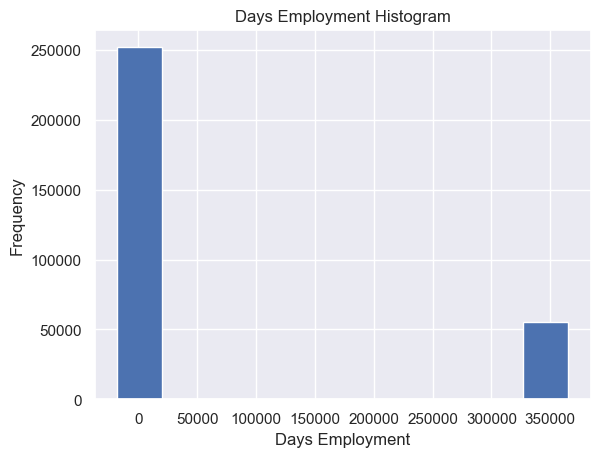

In [60]:
application_train["DAYS_EMPLOYED"].plot.hist(title="Days Employment Histogram")
_ = plt.xlabel("Days Employment")


Examinons les clients anormaux pour voir s'ils ont des taux de défaut plus élevés ou plus bas que le reste des clients.

In [61]:
anom = application_train[application_train["DAYS_EMPLOYED"] == 365243]
non_anom = application_train[application_train["DAYS_EMPLOYED"] != 365243]
print(
    f"Les non-anomalies font défaut sur {100 * non_anom["TARGET"].mean():.2f} % des prêts"
)
print(f"Les anomalies font défaut sur {100 * anom["TARGET"].mean():.2f} % des prêts")
print(f"Il y a {len(anom)} jours d'emploi anormaux")

Les non-anomalies font défaut sur 8.66 % des prêts
Les anomalies font défaut sur 5.40 % des prêts
Il y a 55374 jours d'emploi anormaux


C'est extrêmement intéressant ! Il s'avère que les anomalies ont un taux de défaut plus faible.

La gestion des anomalies dépend de la situation précise, il n'y a pas de règles fixes. Une des approches les plus sûres consiste à remplacer les anomalies par une valeur manquante (comme np.nan) puis à les imputer (remplir) avant l'entraînement du modèle de machine learning. Dans ce cas, étant donné que toutes les anomalies ont exactement la même valeur, il est judicieux de les remplir avec la même valeur, au cas où ces prêts auraient quelque chose en commun. Ces valeurs anormales semblent avoir une certaine importance, donc il est préférable d'indiquer au modèle de machine learning si ces valeurs ont été imputées. La solution consiste à remplir ces valeurs anormales par np.nan et à créer une nouvelle colonne booléenne qui indique si la valeur était une anomalie ou non.

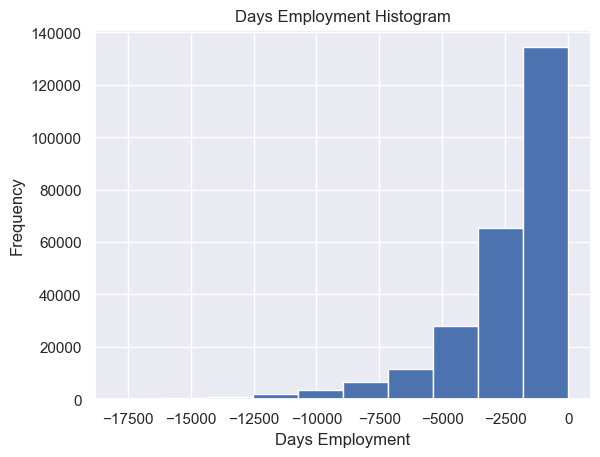

In [62]:
# Create an anomalous flag column
application_train["DAYS_EMPLOYED_ANOM"] = application_train["DAYS_EMPLOYED"] == 365243

# Replace the anomalous values with nan
application_train.loc[application_train["DAYS_EMPLOYED"] == 365243, "DAYS_EMPLOYED"] = (
    np.nan
)

application_train["DAYS_EMPLOYED"].plot.hist(title="Days Employment Histogram")
_ = plt.xlabel("Days Employment")

application_train = application_train.drop(columns=["DAYS_EMPLOYED_ANOM"])

La distribution semble maintenant beaucoup plus conforme à ce que l'on attendait, et nous avons également créé une nouvelle colonne pour indiquer au modèle que ces valeurs étaient initialement des anomalies (car nous devrons remplacer les nan par une valeur, probablement la médiane de la colonne). Les autres colonnes avec des jours dans le DataFrame semblent conformes à nos attentes, sans valeurs aberrantes évidentes.

Point extrêmement important : tout ce que nous faisons aux données d'entraînement doit également être appliqué aux données de test. Assurons-nous de créer la nouvelle colonne et de remplacer les valeurs existantes par np.nan dans les données de test.

In [63]:
application_train.shape

(307507, 81)

### Feature engineering

**Ratio crédit/revenu :** Le montant du crédit demandé par rapport au revenu total.

In [64]:
application_train["CREDIT_INCOME_RATIO"] = (
    application_train["AMT_CREDIT"] / application_train["AMT_INCOME_TOTAL"]
)

**Ratio annuité/revenu :** Le montant de l'annuité (paiement annuel) par rapport au revenu total.

In [65]:
application_train["ANNUITY_INCOME_RATIO"] = (
    application_train["AMT_ANNUITY"] / application_train["AMT_INCOME_TOTAL"]
)

**Ratio annuité/crédit :** Le montant de l'annuité par rapport au montant total du crédit.

In [66]:
application_train["ANNUITY_CREDIT_RATIO"] = (
    application_train["AMT_ANNUITY"] / application_train["AMT_CREDIT"]
)

In [67]:
application_train.shape

(307507, 84)

Des info provenant du fichier bureau 

In [68]:
bureau = pd.read_csv("./data/bureau.csv")
installments_payments = pd.read_csv("./data/installments_payments.csv")
credit_card_balance = pd.read_csv("./data/credit_card_balance.csv")

In [69]:
bureau.head()

,SK_ID_CURR,SK_ID_BUREAU,CREDIT_ACTIVE,CREDIT_CURRENCY,DAYS_CREDIT,CREDIT_DAY_OVERDUE,DAYS_CREDIT_ENDDATE,DAYS_ENDDATE_FACT,AMT_CREDIT_MAX_OVERDUE,CNT_CREDIT_PROLONG,AMT_CREDIT_SUM,AMT_CREDIT_SUM_DEBT,AMT_CREDIT_SUM_LIMIT,AMT_CREDIT_SUM_OVERDUE,CREDIT_TYPE,DAYS_CREDIT_UPDATE,AMT_ANNUITY
0,215354,5714462,Closed,currency 1,-497,0,-153.0,-153.0,NaN,0,91323.0,0.0,NaN,0.0,Consumer credit,-131,NaN
1,215354,5714463,Active,currency 1,-208,0,1075.0,NaN,NaN,0,225000.0,171342.0,NaN,0.0,Credit card,-20,NaN
2,215354,5714464,Active,currency 1,-203,0,528.0,NaN,NaN,0,464323.5,NaN,NaN,0.0,Consumer credit,-16,NaN
3,215354,5714465,Active,currency 1,-203,0,NaN,NaN,NaN,0,90000.0,NaN,NaN,0.0,Credit card,-16,NaN
4,215354,5714466,Active,currency 1,-629,0,1197.0,NaN,77674.5,0,2700000.0,NaN,NaN,0.0,Consumer credit,-21,NaN


In [70]:
# Nombre de crédits actifs par client
bureau_active = (
    bureau[bureau["CREDIT_ACTIVE"] == "Active"]
    .groupby("SK_ID_CURR")
    .size()
    .reset_index(name="bureau_active_loans_count")
)

# Moyenne des jours de retard
bureau_overdue = bureau.groupby("SK_ID_CURR")["CREDIT_DAY_OVERDUE"].mean().reset_index()
bureau_overdue.rename(
    columns={"CREDIT_DAY_OVERDUE": "bureau_avg_days_overdue"}, inplace=True
)

# Fusionner les deux avec l'identifiant client
bureau_features = pd.merge(bureau_active, bureau_overdue, on="SK_ID_CURR", how="outer")

In [71]:
# Calcul du nombre total de paiements et des paiements en retard pour chaque client
installments_payments["DAYS_LATE"] = (
    installments_payments["DAYS_ENTRY_PAYMENT"]
    - installments_payments["DAYS_INSTALMENT"]
)
installments_payments["LATE_PAYMENT"] = installments_payments["DAYS_LATE"] > 0

# Calcul du pourcentage de paiements en retard pour chaque client
late_payment_percentage = (
    installments_payments.groupby("SK_ID_CURR")["LATE_PAYMENT"].mean().reset_index()
)
late_payment_percentage.rename(
    columns={"LATE_PAYMENT": "installment_late_payment_percentage"}, inplace=True
)

In [72]:
# Calcul de l'utilisation moyenne du crédit et des jours de retard
credit_card_balance["CREDIT_USAGE"] = (
    credit_card_balance["AMT_BALANCE"] / credit_card_balance["AMT_CREDIT_LIMIT_ACTUAL"]
)
credit_usage = (
    credit_card_balance.groupby("SK_ID_CURR")["CREDIT_USAGE"].mean().reset_index()
)
credit_usage.rename(columns={"CREDIT_USAGE": "credit_card_avg_usage"}, inplace=True)

# Moyenne des jours de retard pour les paiements de cartes de crédit
avg_days_past_due = (
    credit_card_balance.groupby("SK_ID_CURR")["SK_DPD"].mean().reset_index()
)
avg_days_past_due.rename(
    columns={"SK_DPD": "credit_card_avg_days_past_due"}, inplace=True
)

# Fusionner les deux avec l'identifiant client
credit_card_features = pd.merge(
    credit_usage, avg_days_past_due, on="SK_ID_CURR", how="outer"
)

In [73]:
# Fusion avec les informations de bureau
application_train = pd.merge(
    application_train, bureau_features, on="SK_ID_CURR", how="left"
)

In [74]:
# Fusion avec les informations de bureau
application_train = pd.merge(
    application_train, bureau_features, on="SK_ID_CURR", how="left"
)

# Fusion avec les informations des paiements des échéances
application_train = pd.merge(
    application_train, late_payment_percentage, on="SK_ID_CURR", how="left"
)

# Fusion avec les informations d'utilisation de la carte de crédit
application_train = pd.merge(
    application_train, credit_card_features, on="SK_ID_CURR", how="left"
)

In [75]:
application_train["credit_card_avg_usage_missing"] = (
    application_train["credit_card_avg_usage"].isna().astype(int)
)
application_train["credit_card_avg_usage"].fillna(0, inplace=True)

In [76]:
application_train["credit_card_avg_days_past_due_missing"] = (
    application_train["credit_card_avg_days_past_due"].isna().astype(int)
)
application_train["credit_card_avg_days_past_due"].fillna(0, inplace=True)

In [77]:
application_train.shape

(307507, 93)

In [78]:
missing_values_table(application_train).head()

Le DataFrame sélectionné contient 93 colonnes.
Il y a 34 colonnes qui ont des valeurs manquantes.


,Valeurs Manquantes,% des Valeurs Totales
FLOORSMAX_MODE,153019,49.8
FLOORSMAX_AVG,153019,49.8
FLOORSMAX_MEDI,153019,49.8
YEARS_BEGINEXPLUATATION_MODE,150006,48.8
YEARS_BEGINEXPLUATATION_MEDI,150006,48.8


In [79]:
application_train.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_2,EXT_SOURCE_3,YEARS_BEGINEXPLUATATION_AVG,FLOORSMAX_AVG,YEARS_BEGINEXPLUATATION_MODE,FLOORSMAX_MODE,YEARS_BEGINEXPLUATATION_MEDI,FLOORSMAX_MEDI,TOTALAREA_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,CREDIT_INCOME_RATIO,ANNUITY_INCOME_RATIO,ANNUITY_CREDIT_RATIO,bureau_active_loans_count_x,bureau_avg_days_overdue_x,bureau_active_loans_count_y,bureau_avg_days_overdue_y,installment_late_payment_percentage,credit_card_avg_usage,credit_card_avg_days_past_due,credit_card_avg_usage_missing,credit_card_avg_days_past_due_missing
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.018801,-9461,-637.0,-3648.0,-2120,1,1,0,1,1,0,Laborers,1.0,2,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.262949,0.139376,0.9722,0.0833,0.9722,0.0833,0.9722,0.0833,0.0149,No,2.0,2.0,2.0,2.0,-1134.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0,2.007889,0.121978,0.060749,2.0,0.0,2.0,0.0,0.000000,0.0,0.0,1,1
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,Family,State servant,Higher education,Married,House / apartment,0.003541,-16765,-1188.0,-1186.0,-291,1,1,0,1,1,0,Core staff,2.0,1,1,MONDAY,11,0,0,0,0,0,0,School,0.622246,NaN,0.9851,0.2917,0.9851,0.2917,0.9851,0.2917,0.0714,No,1.0,0.0,1.0,0.0,-828.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,4.790750,0.132217,0.027598,1.0,0.0,1.0,0.0,0.000000,0.0,0.0,1,1
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,135000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.010032,-19046,-225.0,-4260.0,-2531,1,1,1,1,1,0,Laborers,1.0,2,2,MONDAY,9,0,0,0,0,0,0,Government,0.555912,0.729567,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,-815.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,2.000000,0.100000,0.050000,NaN,0.0,NaN,0.0,0.000000,0.0,0.0,1,1
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,297000.0,Unaccompanied,Working,Secondary / secondary special,Civil marriage,House / apartment,0.008019,-19005,-3039.0,-9833.0,-2437,1,1,0,1,0,0,Laborers,2.0,2,2,WEDNESDAY,17,0,0,0,0,0,0,Business Entity Type 3,0.650442,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,0.0,2.0,0.0,-617.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,2.316167,0.219900,0.094941,NaN,NaN,NaN,NaN,0.000000,0.0,0.0,0,0
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,513000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.028663,-19932,-3038.0,-4311.0,-3458,1,1,0,1,0,0,Core staff,1.0,2,2,THURSDAY,11,0,0,0,0,1,1,Religion,0.322738,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0

### Correlation

Maintenant que nous avons traité les variables catégorielles et les valeurs aberrantes, poursuivons l'analyse exploratoire des données (EDA). Une façon d'essayer de comprendre les données est de rechercher des corrélations entre les caractéristiques et la cible. Nous pouvons calculer le coefficient de corrélation de Pearson entre chaque variable et la cible en utilisant la méthode .corr du DataFrame.

Le coefficient de corrélation n'est pas la meilleure méthode pour représenter la "pertinence" d'une caractéristique, mais il nous donne une idée des relations possibles au sein des données. Voici quelques interprétations générales de la valeur absolue du coefficient de corrélation :

- 0.00 - 0.19 : “très faible”
- 0.20 - 0.39 : “faible”
- 0.40 - 0.59 : “modéré”
- 0.60 - 0.79 : “fort”
- 0.80 - 1.0 : “très fort”

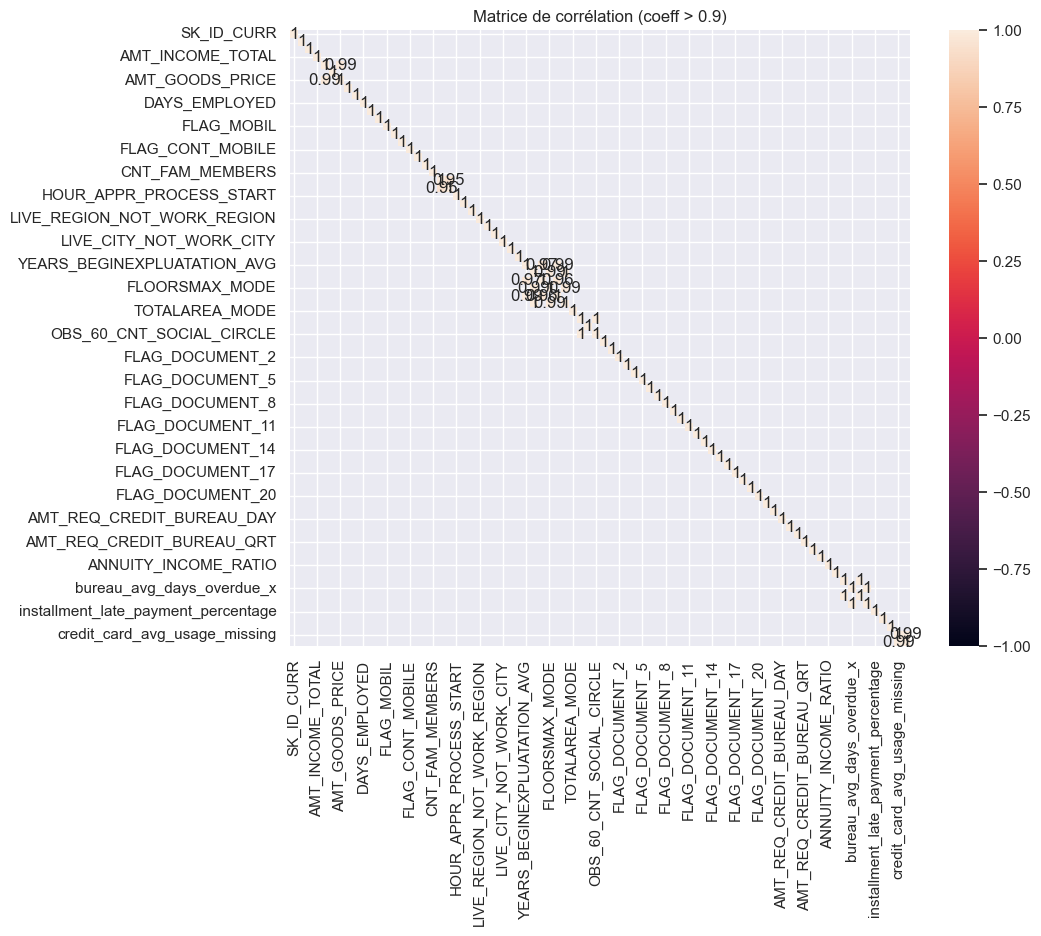

In [80]:
# Calculer la matrice de corrélation
df_num = application_train.select_dtypes(include=["float64", "int64"])

corr_matrix = df_num.corr().abs()

# Filtrer les coefficients de corrélation > 0.9
corr_filtered = corr_matrix[(corr_matrix > 0.9)]

# Visualiser avec seaborn (optionnel)
plt.figure(figsize=(10, 8))
sns.heatmap(corr_filtered, annot=True, vmin=-1, vmax=1)
plt.title("Matrice de corrélation (coeff > 0.9)")
plt.show()

In [81]:
# # Stocker les variables à supprimer
# high_corr_var = set()
# for i in range(len(corr_matrix.columns)):
#     for j in range(i):
#         if corr_matrix.iloc[i, j] > 0.9:
#             var_name = corr_matrix.columns[i]
#             high_corr_var.add(var_name)

# # Supprimer les variables fortement corrélées
# application_train = application_train.drop(columns=high_corr_var)

# # Afficher les variables supprimées
# print(
#     f"Les {len(high_corr_var)} variables suivantes ont été supprimées en raison de corrélations élevées :\n{high_corr_var}"
# )


### Corrélation avec la variable ``TARGET``

In [82]:
# Find correlations with the target and sort
correlations = (
    application_train.select_dtypes(include=["int64", "float64"])
    .corr()["TARGET"]
    .sort_values()
)

# Display correlations
print("Most Positive Correlations:")
print(correlations.tail(15))

Most Positive Correlations:
FLAG_DOCUMENT_3                        0.044341
REG_CITY_NOT_LIVE_CITY                 0.044394
FLAG_EMP_PHONE                         0.045984
REG_CITY_NOT_WORK_CITY                 0.050992
DAYS_ID_PUBLISH                        0.051457
DAYS_LAST_PHONE_CHANGE                 0.055219
REGION_RATING_CLIENT                   0.058901
REGION_RATING_CLIENT_W_CITY            0.060895
bureau_active_loans_count_x            0.060932
bureau_active_loans_count_y            0.060932
credit_card_avg_usage                  0.064835
installment_late_payment_percentage    0.070015
DAYS_EMPLOYED                          0.074957
DAYS_BIRTH                             0.078242
TARGET                                 1.000000
Name: TARGET, dtype: float64


In [83]:
print("Most Negative Correlations:")
print(correlations.head(15))


Most Negative Correlations:
EXT_SOURCE_3                            -0.178926
EXT_SOURCE_2                            -0.160471
FLOORSMAX_AVG                           -0.044009
FLOORSMAX_MEDI                          -0.043773
FLOORSMAX_MODE                          -0.043231
AMT_GOODS_PRICE                         -0.039647
REGION_POPULATION_RELATIVE              -0.037225
TOTALAREA_MODE                          -0.032599
AMT_CREDIT                              -0.030371
FLAG_DOCUMENT_6                         -0.028603
HOUR_APPR_PROCESS_START                 -0.024164
FLAG_PHONE                              -0.023801
credit_card_avg_days_past_due_missing   -0.013737
credit_card_avg_usage_missing           -0.013321
AMT_ANNUITY                             -0.012818
Name: TARGET, dtype: float64


Examinons quelques corrélations plus significatives : DAYS_BIRTH est la corrélation la plus positive (à l'exception de TARGET, car la corrélation d'une variable avec elle-même est toujours égale à 1 !). Selon la documentation, DAYS_BIRTH représente l'âge du client en jours au moment du prêt, exprimé en jours négatifs (pour une raison quelconque !). La corrélation est positive, mais la valeur de cette variable est en réalité négative, ce qui signifie qu'à mesure que le client vieillit, il est moins susceptible de faire défaut sur son prêt (c'est-à-dire que TARGET == 0). C'est un peu déroutant, donc nous allons prendre la valeur absolue de cette variable et la corrélation deviendra négative.

Effect of Age on Repayment

In [84]:
# Find the correlation of the positive days since birth and target
application_train["DAYS_BIRTH"] = abs(application_train["DAYS_BIRTH"])
application_train["DAYS_BIRTH"].corr(application_train["TARGET"])

np.float64(-0.078242160036194)

À mesure que le client vieillit, il existe une relation linéaire négative avec la cible, ce qui signifie qu'à mesure que les clients vieillissent, ils ont tendance à rembourser leurs prêts à temps plus souvent.

Commençons par examiner cette variable. Tout d'abord, nous pouvons créer un histogramme de l'âge. Nous mettrons l'axe des x en années pour rendre le graphique un peu plus compréhensible.

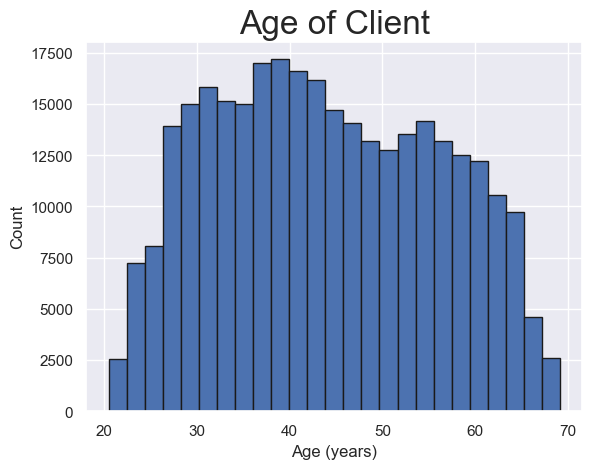

In [85]:
# Plot the distribution of ages in years
plt.hist(application_train["DAYS_BIRTH"] / 365, edgecolor="k", bins=25)
plt.title("Age of Client", fontsize=24)
plt.xlabel("Age (years)")
_ = plt.ylabel("Count")


En soi, la distribution de l'âge ne nous révèle pas grand-chose, si ce n'est qu'il n'y a pas de valeurs aberrantes, car tous les âges semblent raisonnables. Pour visualiser l'effet de l'âge sur la cible, nous allons ensuite créer un graphique d'estimation de densité par noyau (KDE), coloré en fonction de la valeur de la cible. Un graphique d'estimation de densité par noyau montre la distribution d'une seule variable et peut être considéré comme un histogramme lissé (il est créé en calculant un noyau, généralement un noyau gaussien, à chaque point de données, puis en moyennant tous les noyaux individuels pour développer une seule courbe lisse). Nous utiliserons la fonction kdeplot de Seaborn pour ce graphique.

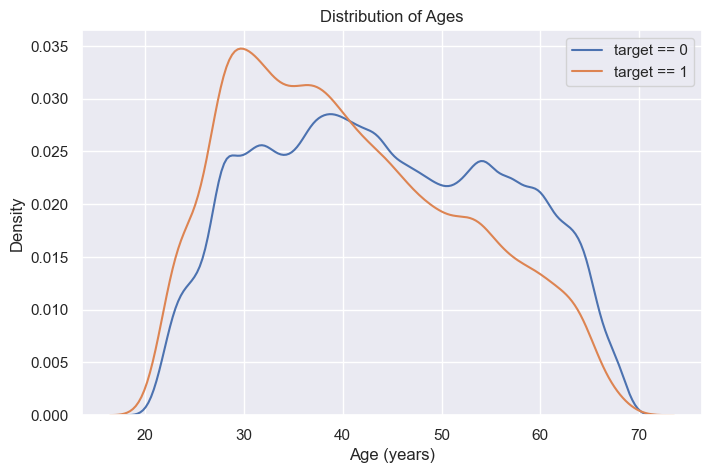

In [86]:
plt.figure(figsize=(8, 5))

# KDE plot of loans that were repaid on time
sns.kdeplot(
    application_train.loc[application_train["TARGET"] == 0, "DAYS_BIRTH"] / 365,
    label="target == 0",
)

# KDE plot of loans which were not repaid on time
sns.kdeplot(
    application_train.loc[application_train["TARGET"] == 1, "DAYS_BIRTH"] / 365,
    label="target == 1",
)

# Labeling of plot
plt.xlabel("Age (years)")
plt.ylabel("Density")
plt.title("Distribution of Ages")
plt.legend()
plt.show()


La courbe correspondant à TARGET == 1 est inclinée vers le bas de l'échelle d'âge. Bien que cela ne soit pas une corrélation significative (avec un coefficient de corrélation de -0,07), cette variable sera probablement utile dans un modèle de machine learning car elle a un impact sur la cible. Examinons cette relation sous un autre angle : le taux moyen de défaut de remboursement des prêts par tranche d'âge.

Pour réaliser ce graphique, nous allons d'abord diviser les catégories d'âge en intervalles de 5 ans chacun. Ensuite, pour chaque intervalle, nous calculons la valeur moyenne de la cible, ce qui nous indique le ratio de prêts qui n'ont pas été remboursés dans chaque catégorie d'âge.

In [87]:
# Age information into a separate dataframe
age_data = application_train[["TARGET", "DAYS_BIRTH"]]
age_data["YEARS_BIRTH"] = age_data["DAYS_BIRTH"] / 365

# Bin the age data
age_data["YEARS_BINNED"] = pd.cut(
    age_data["YEARS_BIRTH"], bins=np.linspace(20, 70, num=11).astype(int)
)
age_data.head(10)


,TARGET,DAYS_BIRTH,YEARS_BIRTH,YEARS_BINNED
0,1,9461,25.920548,"(25, 30]"
1,0,16765,45.931507,"(45, 50]"
2,0,19046,52.180822,"(50, 55]"
3,0,19005,52.068493,"(50, 55]"
4,0,19932,54.608219,"(50, 55]"
5,0,16941,46.413699,"(45, 50]"
6,0,13778,37.747945,"(35, 40]"
7,0,18850,51.643836,"(50, 55]"
8,0,20099,55.065753,"(55, 60]"
9,0,14469,39.641096,"(35, 40]"


In [88]:
# Group by the bin and calculate averages
age_groups = age_data.groupby("YEARS_BINNED").mean()
age_groups


,TARGET,DAYS_BIRTH,YEARS_BIRTH
YEARS_BINNED,,,
"(20, 25]",0.123036,8532.795625,23.377522
"(25, 30]",0.111442,10155.219690,27.822520
"(30, 35]",0.102814,11854.848377,32.479037
"(35, 40]",0.089416,13707.908041,37.555912
"(40, 45]",0.078491,15497.661233,42.459346
"(45, 50]",0.074171,17323.900441,47.462741
"(50, 55]",0.066968,19196.494791,52.593136
"(55, 60]",0.055316,20984.285455,57.491193
"(60, 65]",0.052737,22780.547460,62.412459


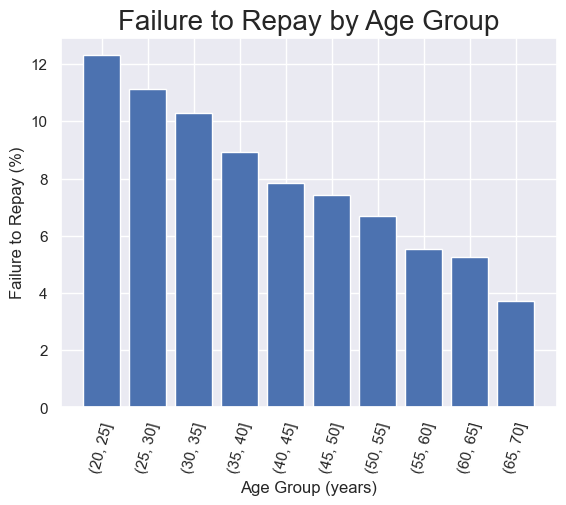

In [89]:
# Graph the age bins and the average of the target as a bar plot
plt.bar(age_groups.index.astype(str), 100 * age_groups["TARGET"])

# Plot labeling
plt.xticks(rotation=75)
plt.xlabel("Age Group (years)")
plt.ylabel("Failure to Repay (%)")
plt.title("Failure to Repay by Age Group", fontsize=20)
plt.show()


Il y a une tendance claire : les jeunes demandeurs sont plus susceptibles de ne pas rembourser le prêt ! Le taux de défaut de remboursement dépasse 10 % pour les trois groupes d'âge les plus jeunes et est en dessous de 5 % pour le groupe d'âge le plus âgé.

C'est une information qui pourrait être directement utilisée par la banque : étant donné que les jeunes clients sont moins susceptibles de rembourser le prêt, peut-être devraient-ils bénéficier de plus d'accompagnement ou de conseils en gestion financière. Cela ne signifie pas que la banque devrait discriminer les jeunes clients, mais il serait judicieux de prendre des mesures de précaution pour aider les jeunes clients à rembourser à temps.

### Imputation des valeurs manquantes

On va fair un imputation des valeurs manquante avec SimpleImputer de sklearn.impute suivant les groupes d'ages:

- Variables catégorielles : imputées avec la valeur la plus fréquente.
- Variables numerique : imputées avec la médiane.

In [90]:
categorical_features = application_train.select_dtypes(
    include="object"
).columns.to_list()

In [91]:
numerical_featues = application_train.select_dtypes(
    include=["int64", "float64"]
).columns.to_list()

In [92]:
num_cat_features = []
for col in numerical_featues[:]:
    if application_train[col].nunique() < 3:
        print(f"La colonne {col} prend les valeurs: {application_train[col].unique()}")
        numerical_featues.remove(col)
        num_cat_features.append(col)

La colonne TARGET prend les valeurs: [1 0]
La colonne FLAG_MOBIL prend les valeurs: [1 0]
La colonne FLAG_EMP_PHONE prend les valeurs: [1 0]
La colonne FLAG_WORK_PHONE prend les valeurs: [0 1]
La colonne FLAG_CONT_MOBILE prend les valeurs: [1 0]
La colonne FLAG_PHONE prend les valeurs: [1 0]
La colonne FLAG_EMAIL prend les valeurs: [0 1]
La colonne REG_REGION_NOT_LIVE_REGION prend les valeurs: [0 1]
La colonne REG_REGION_NOT_WORK_REGION prend les valeurs: [0 1]
La colonne LIVE_REGION_NOT_WORK_REGION prend les valeurs: [0 1]
La colonne REG_CITY_NOT_LIVE_CITY prend les valeurs: [0 1]
La colonne REG_CITY_NOT_WORK_CITY prend les valeurs: [0 1]
La colonne LIVE_CITY_NOT_WORK_CITY prend les valeurs: [0 1]
La colonne FLAG_DOCUMENT_2 prend les valeurs: [0 1]
La colonne FLAG_DOCUMENT_3 prend les valeurs: [1 0]
La colonne FLAG_DOCUMENT_4 prend les valeurs: [0 1]
La colonne FLAG_DOCUMENT_5 prend les valeurs: [0 1]
La colonne FLAG_DOCUMENT_6 prend les valeurs: [0 1]
La colonne FLAG_DOCUMENT_7 prend

In [93]:
application_train = application_train[
    ~application_train.isin([float("inf"), float("-inf")]).any(axis=1)
]

In [95]:
from sklearn.impute import SimpleImputer

# Imputation pour les colonnes catégorielles (stratégie = most_frequent)
categorical_transformer = SimpleImputer(strategy="most_frequent")
application_train[categorical_features + num_cat_features] = (
    categorical_transformer.fit_transform(
        application_train[categorical_features + num_cat_features]
    )
)

# Imputation pour les colonnes numériques (stratégie = median)
numerical_transformer = SimpleImputer(strategy="median")
application_train[numerical_featues] = numerical_transformer.fit_transform(
    application_train[numerical_featues]
)

In [96]:
missing_values_table(application_train)

Le DataFrame sélectionné contient 93 colonnes.
Il y a 0 colonnes qui ont des valeurs manquantes.


In [98]:
application_train.to_pickle("./data_cleaned/data.pkl")